# RTU-grid type comparison

The new `PixelatedLightRTU` subclass has the `rtu_grid_type` keyword, this notebook will walk through the differences between these two methods.  This notebook with reproduce some of the plots from Appendix C of Enzi et al. 2026 and uses the mass profile of "Mock 1" as an example.

## Imports
The various imports we will be using in this notebook.

In [ ]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt

from herculens import (
    PixelGrid,
    PSF,
    Noise,
    MassModel
)
import jax_lensing_profiles
from LensImageRTUGrid import create_transforms_spline, create_transforms_linear_interp
from Herculens_overrides import LensImageRTUGrid, LightModelRTU, PixelatedLightRTU

from astropy.io import fits

## Read in the mask

The arc mask for Mock 1 is provided in the included `.fits` file.  The full mock data is also included in this file along with the best fit from SVI as presented in the paper.  For this example we just need the mask.

In [ ]:
mask = jnp.array(fits.getdata('mock_paper_data.fits', extname="mask").astype(bool))

## Set up a Herculens pixel grid and noise

Make a standard Herculens `PixelGrid` and `Noise` classes for our observations that is 200x200 pixels with a pixel size of 0.031 arcseconds and an exposure time of 2000 seconds.

In [3]:
npix = 200  # number of pixel on a side
pix_scl = 0.031  # pixel size in arcsec

half_size = npix * pix_scl / 2.
ra_at_xy_0 = dec_at_xy_0 = -half_size + pix_scl / 2.

transform_pix2angle = pix_scl * np.eye(2)
pixel_grid = PixelGrid(
    nx=npix, ny=npix, 
    ra_at_xy_0=ra_at_xy_0, dec_at_xy_0=dec_at_xy_0,
    transform_pix2angle=transform_pix2angle
)

xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent

# bounds used for plotting
half_pixel_scale = 0.5 * pix_scl
bounds = [
    x_axis[0] - half_pixel_scale,
    x_axis[-1] + half_pixel_scale,
    y_axis[0] - half_pixel_scale, 
    y_axis[-1] + half_pixel_scale
]

print(f"image size : ({npix}, {npix}) pixels")
print(f"pixel size : {pix_scl} arcsec")
print(f"x range    : {xgrid[0, 0], xgrid[0, -1]} arcsec")
print(f"y range    : {ygrid[0, 0], ygrid[-1, 0]} arcsec")

psf = PSF(psf_type='GAUSSIAN', fwhm=pix_scl*2, pixel_size=pix_scl)
noise = Noise(npix, npix, exposure_time=2000.0)

image size : (200, 200) pixels
pixel size : 0.031 arcsec
x range    : (-3.0845000000000002, 3.0844999999999994) arcsec
y range    : (-3.0845000000000002, 3.0844999999999994) arcsec


## The lens model

As we will be calling the `ray_shooting` methods by hand rather than using the `model` method directly we only need to set up one `LensImageRTUGrid` to test both the "linear" and "spline" `rtu_grid_type` values.

In [4]:
lens_mass_input = MassModel(["EPL","NFW","SHEAR"])
pixel_grid_shape = 64

source_input_rtu = LightModelRTU([
    PixelatedLightRTU(
        interpolation_type='fast_bilinear',
        derivative_type='autodiff',
        rtu_grid=True,
        allow_extrapolation=False
    )
], kwargs_pixelated={'num_pixels': pixel_grid_shape})

kwargs_numerics = {'supersampling_factor': 4}

lens_image = LensImageRTUGrid(
    pixel_grid, psf, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input_rtu,
    kwargs_numerics=kwargs_numerics,
    source_arc_mask=mask
)

In [5]:
kwargs_lens = [
    # EPL
    {'theta_E': 1.5, 'gamma': 2.1, 'e1': 0.1, 'e2': -0.05, 'center_x': 0.01, 'center_y': 0.0},
    # NFW
    {'kappa_s': 10**0.3, 'R_s': 10**-1.42, 'center_x': -1.6, 'center_y': 0.0},
    # SHEAR
    {'gamma1': -0.03, 'gamma2': 0.02, 'ra_0': 0.0, 'dec_0': 0.0}
]

## Get the supersampled mask

We will be working with the supersampled grid later on and will want to be able to pull out the pixels inside the source arc mask.

In [6]:
mask_ss = np.kron(
    mask,
    np.ones([
        kwargs_numerics['supersampling_factor'],
        kwargs_numerics['supersampling_factor']
    ])
).flatten().astype(bool)
mask_flatten = mask.flatten().astype(bool)

## Tracing rays and constructing the transform

The RTU-grid constructs its transformation using the rays cast from the center of each pixel *inside* the arc mask.  This is done on the observed pixels rather than the supersampled ones to save on computation time.

In [7]:
# the observed pixel grid
obs_x, obs_y = lens_image.Grid.pixel_coordinates
obs_x = obs_x.flatten()
obs_y = obs_y.flatten()

# only trace the masked pixels
traced_obs_x_mask, traced_obs_y_mask = lens_image.MassModel.ray_shooting(
    obs_x[mask_flatten],
    obs_y[mask_flatten],
    kwargs_lens
)

# standardize the traced rays to create a "mass-sheet like" invarient space
# by subtracting by the mean and dividing my the minimum standard deivation
# in either the x or y direction (e.g. make sure both coordiantes are scaled
# by the same value)
traced_obs_mask = jnp.stack([traced_obs_x_mask, traced_obs_y_mask]).T
mu = traced_obs_mask.mean(axis=0)
scale = traced_obs_mask.std(axis=0).min()
traced_obs_mask_standard = (traced_obs_mask - mu) / scale

Plotting these traced points we can see the form a complicated caustic structure that has a higher density of points in the center than on the outside.

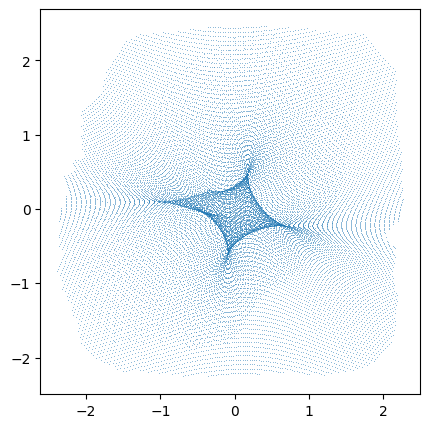

In [8]:
fig = plt.figure(figsize=(5, 5))
ax = plt.subplot(111)
ax.plot(*traced_obs_mask_standard.T, ',', alpha=0.5)
ax.set_aspect(1)

Now with the masked rays traced and standardized we can create our transformations.  Internally, if `rtu_grid_type='spline'` the `create_transforms_spline` class is used, otherwise the `create_transforms_linear_interp` is used.  These two methods take different approaches to defining the transformation function that brings the observed rays into uniform square.  For the spline transformation we need to input the degree of the polynomial used to approximate the *inverse transformation* (see Appendix C for more details).  To match Appendix C we will use a `deg=21`.

In [9]:
# pick a degree and create a spline transform class
deg = 21
ips, _, _ = create_transforms_spline(traced_obs_mask_standard, deg=deg)
# the transform function is defined as the `fwd_transform` method
transform_spline = jax.jit(ips.fwd_transform)

# create a linear interpolation class
ips_interp, _, _ = create_transforms_linear_interp(traced_obs_mask_standard)
# the transform function is defined as the `fwd_transform` method
transform_interp = jax.jit(ips_interp.fwd_transform)

Note: The `rev_transform` methods are used to convert points on the unit square back into standardized coordinates and the values of `mu` and `scale` are used to convert those values back into observed `x` and `y` positions.  These functions are used with `return_source_pixels_coords=True` is set inside a `model` call.

## Apply the transform to all rays

With the transform functions defined, we can now pass *all* the supersampled rays into this function.  These rays will need to be standardized before being transformed.

In [10]:
# the supersampled grid
ss_x, ss_y = lens_image.ImageNumerics.coordinates_evaluate

# trace the rays onto the soruce plane
traced_ss_x, traced_ss_y = lens_image.MassModel.ray_shooting(ss_x, ss_y, kwargs_lens)
traced_ss = jnp.stack([traced_ss_x, traced_ss_y]).T

# standardize using the same `mu` and `scale` as calculated with the masked rays
traced_ss_standard = (traced_ss - mu) / scale

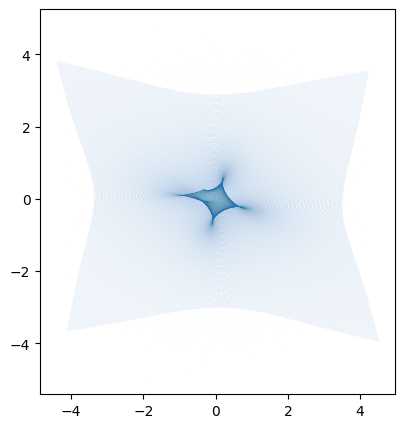

In [11]:
fig = plt.figure(figsize=(5, 5))
ax = plt.subplot(111)
ax.plot(*traced_ss_standard.T, ',', alpha=0.01)
ax.set_aspect(1)

In [12]:
grid_ss_transformed_spline = transform_spline(traced_ss_standard)
grid_ss_transformed_interp = transform_interp(traced_ss_standard)

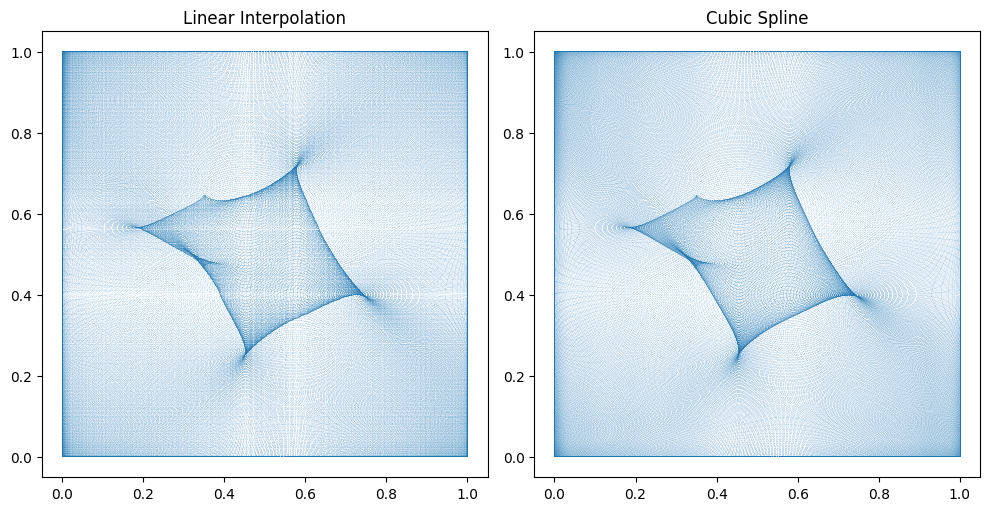

In [13]:
fig = plt.figure(figsize=(10, 5))

plt.subplot(121)
ax = plt.gca()
ax.set_rasterization_zorder(1)
# supersampled points after transform, should not show any banding
plt.plot(*grid_ss_transformed_interp.T, ',', alpha=0.1, zorder=0)
plt.title('Linear Interpolation')
ax.set_aspect(1)

plt.subplot(122)
ax = plt.gca()
ax.set_rasterization_zorder(1)
# supersampled points after transform, should not show any banding
plt.plot(*grid_ss_transformed_spline.T, ',', alpha=0.1, zorder=0)
plt.title('Cubic Spline')
ax.set_aspect(1)

plt.tight_layout()

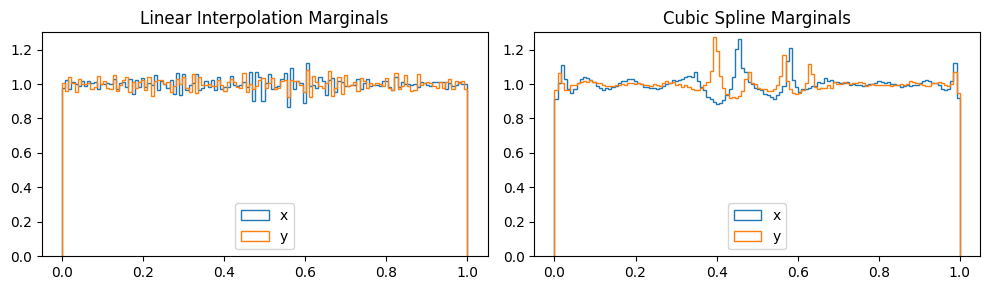

In [14]:
fig = plt.figure(figsize=(10, 3))

ax = plt.subplot(121)
ax.hist(grid_ss_transformed_interp[mask_ss].T[0], bins=128, histtype='step', density=True, label='x')
ax.hist(grid_ss_transformed_interp[mask_ss].T[1], bins=128, histtype='step', density=True, label='y')
plt.title('Linear Interpolation Marginals')
plt.ylim(0, 1.3)
plt.legend()

ax = plt.subplot(122)
ax.hist(grid_ss_transformed_spline[mask_ss].T[0], bins=128, histtype='step', density=True, label='x')
ax.hist(grid_ss_transformed_spline[mask_ss].T[1], bins=128, histtype='step', density=True, label='y')
plt.title('Cubic Spline Marginals')
plt.ylim(0, 1.3)
plt.legend()

plt.tight_layout();

We can clearly see the difference between these two transformations.  When linear interpolation is used we can see clear banding artifacts associated with the points of the caustics.  The transformation is designed to make the x and y marginals in this plot uniform.  Linear interpolation it does a very good job with this, but at the expense of creating under-densities when viewed in the 2D space.

By applying some smoothing to this transformation function, the spline method is able to avoid these issues in the 2D space at the expense of x and y marginals are not as uniform as the linear interpolation.  As the 2D space is the one we actually care about in this case, the spline method is the recommended one for use.

## Speed comparisons

As one final note, care has been taken to ensure that the `spline` method is computationally efferent in comparison to the linear interpolation method.  Below we create a function that takes in the ray traced points, defines the transformation, and applies it to check the speed of both methods.

In [15]:
@jax.jit
def d1(traced_obs_mask_standard, traced_ss_standard):
    ips, _, _ = create_transforms_spline(traced_obs_mask_standard, deg=deg)
    return ips.fwd_transform(traced_ss_standard)


@jax.jit
def d2(traced_obs_mask_standard, traced_ss_standard):
    ips, _, _ = create_transforms_linear_interp(traced_obs_mask_standard)
    return ips.fwd_transform(traced_ss_standard)

In [16]:
# call once to compile
test1 = d1(traced_obs_mask_standard, traced_ss_standard)
test2 = d2(traced_obs_mask_standard, traced_ss_standard)

In [17]:
%timeit jax.block_until_ready(d1(traced_obs_mask_standard, traced_ss_standard))

116 ms ± 13.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
%timeit jax.block_until_ready(d2(traced_obs_mask_standard, traced_ss_standard))

111 ms ± 3.05 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


This simple example shows that overall the `spline` method is just a touch slower than the linear interpolation method.